In [1]:
%load_ext autoreload
%autoreload 2
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
paradigm = P300(resample=32, tmin=0, tmax=1, fmin=1, fmax=16)
dataset = BNCI2014008()

In [3]:
subject, session, run = 2, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied
0 bad epochs dropped


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.938 sec
Baseline,off


In [4]:
scaler= Scaler(scalings='mean', with_mean=False)
epochs._data = scaler.fit_transform(epochs._data)

In [5]:
X = epochs.get_data()
y = labels
print(X.shape)

(4200, 8, 16)


In [6]:
hoda = HODA(max_iter=128, rank=(3,3), tol=0, initialize ='random', verbose=True, toeplitz=1, taper=1, solver='svd')
hoda.fit(X,y)

Iteration 0  updates: [3.55677186 4.06538746]  objective: 0.25134685385820643
Iteration 1  updates: [2.35140469 2.0699244 ]  objective: 0.30911349336046096
Iteration 2  updates: [1.95912145 1.19188096]  objective: 0.2971515211268196
Iteration 3  updates: [1.96376437 0.65822016]  objective: 0.3145611426993191
Iteration 4  updates: [1.99503075 0.5751881 ]  objective: 0.31397878103789073
Iteration 5  updates: [1.99562001 0.29301398]  objective: 0.3197440051675146
Iteration 6  updates: [0.15633412 0.25885243]  objective: 0.31882113421118335
Iteration 7  updates: [0.15074736 0.13467306]  objective: 0.32108159802978314
Iteration 8  updates: [0.07256587 0.12021705]  objective: 0.32046561524445144
Iteration 9  updates: [0.06806344 0.06312341]  objective: 0.32143779487761154
Iteration 10  updates: [0.03367217 0.05664212]  objective: 0.32110778388883
Iteration 11  updates: [0.0311206  0.02980688]  objective: 0.32154595168035666
Iteration 12  updates: [0.01579619 0.02681631]  objective: 0.3213807

Iteration 106  updates: [1.51237505e-14 9.73146976e-15]  objective: 0.32160716863115674
Iteration 107  updates: [8.17962538e-15 2.03263290e-14]  objective: 0.32160716863115657
Iteration 108  updates: [7.51078619e-15 7.38408112e-15]  objective: 0.32160716863115657
Iteration 109  updates: [7.14310223e-15 3.72481071e-14]  objective: 0.3216071686311567
Iteration 110  updates: [1.22252771e-14 1.05785621e-14]  objective: 0.32160716863115685
Iteration 111  updates: [5.11084696e-15 2.38865943e-14]  objective: 0.32160716863115674
Iteration 112  updates: [1.24688499e-14 1.55823346e-14]  objective: 0.32160716863115685
Iteration 113  updates: [1.24883894e-14 8.10703190e-15]  objective: 0.32160716863115674
Iteration 114  updates: [5.62227625e-15 9.91076207e-15]  objective: 0.3216071686311568
Iteration 115  updates: [9.64398622e-15 1.88700714e-14]  objective: 0.3216071686311569
Iteration 116  updates: [1.21816858e-14 2.55490187e-14]  objective: 0.32160716863115674
Iteration 117  updates: [1.29874784

HODA(initialize='random', max_iter=128, rank=(3, 3), solver='svd', tol=0,
     verbose=True)

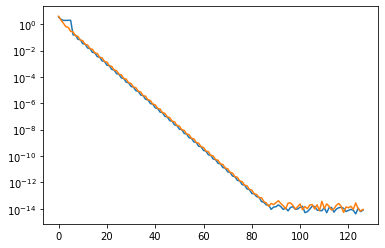

In [7]:
plt.semilogy(hoda.updates_[:,:hoda.iter_].T)
plt.show()

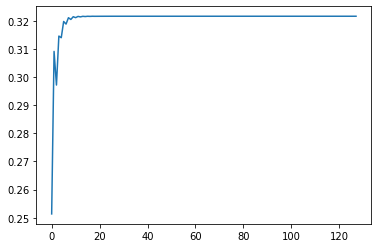

In [8]:
plt.plot(hoda.objective_)
plt.show()

(3, 3)


/tmp/ipykernel_134836/2637232329.py:16: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


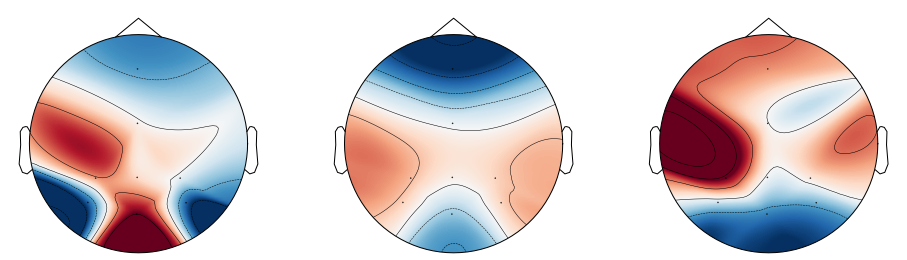

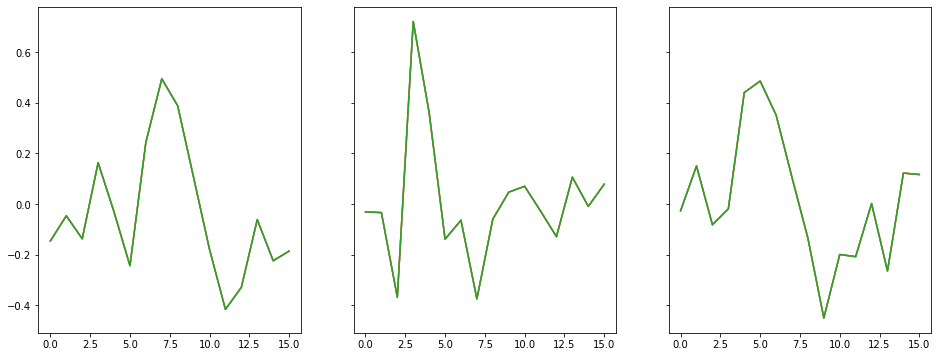

In [9]:
print(hoda.rank_)
for k in range(2):
    Uk = hoda.projs_[k]
    vmax = np.max(np.abs(Uk))
    fig, axs = plt.subplots(1,Uk.shape[1], figsize=(16,6), sharex=True, sharey=True)
    if Uk.shape[1]==1:
        axs = [axs]
    for i in range(Uk.shape[1]):
        if k==0:
            plot_topomap(Uk[:,i], epochs.info, axes=axs[i], show=False)        
        elif k == 1:
            for i in range(Uk.shape[1]):
                axs[i].plot(Uk[:,i])
        else:
            sns.heatmap(Uk, cmap='RdBu_r', vmin=-vmax, vmax=vmax, ax=axs[i])
    fig.show()

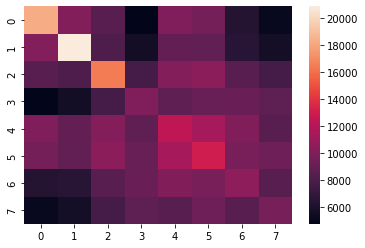

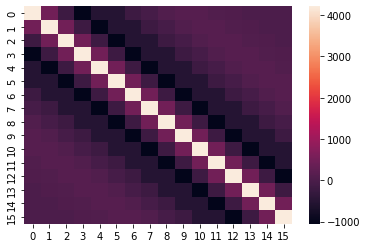

In [10]:
for k in range(2):
    sns.heatmap(hoda.scatter_w_[k])
    plt.show()

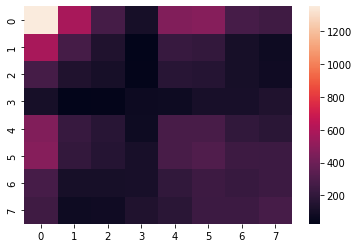

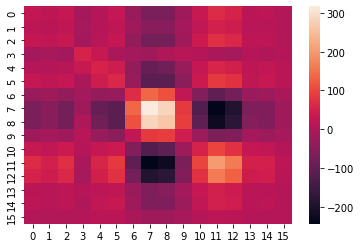

In [11]:
for k in range(2):
    sns.heatmap(hoda.scatter_b_[k])
    plt.show()

/tmp/ipykernel_134836/244461026.py:15: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


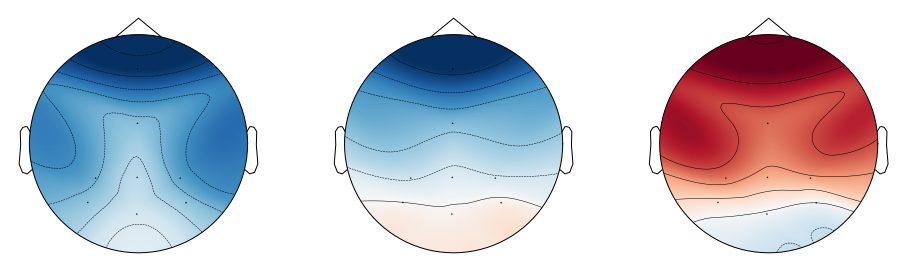

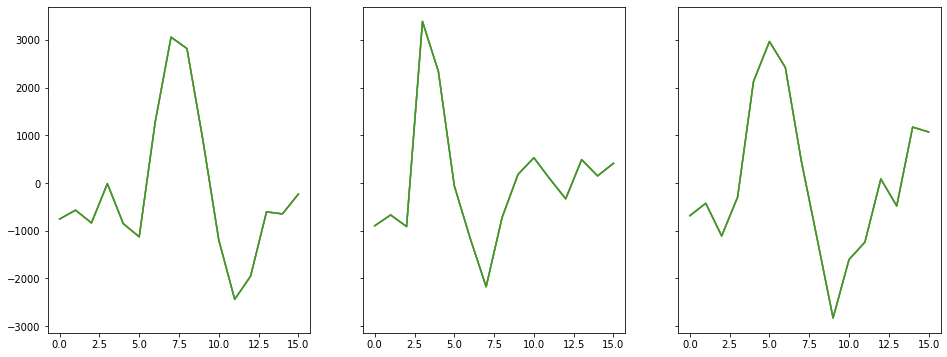

In [12]:
for k in range(2):
    patterns = (hoda.projs_[k].T@hoda.scatter_w_[k]).T
    vmax = np.max(np.abs(Uk))
    fig, axs = plt.subplots(1,patterns.shape[1], figsize=(16,6), sharex=True, sharey=True)
    if Uk.shape[1]==1:
        axs = [axs]
    for i in range(patterns.shape[1]):
        if k==0:
            plot_topomap(patterns[:,i], epochs.info, axes=axs[i], show=False)        
        elif k == 1:
            for i in range(patterns.shape[1]):
                axs[i].plot(patterns[:,i])
        else:
            sns.heatmap(patterns, cmap='RdBu_r', vmin=-vmax, vmax=vmax, ax=axs[i])
    fig.show()

In [13]:
Xt = hoda.transform(X)

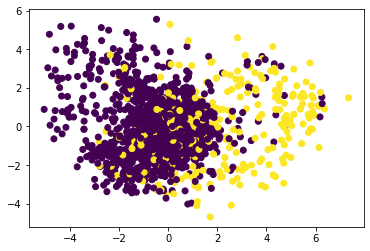

In [14]:
pca = PCA(n_components=2)
X_pc = pca.fit_transform(Xt)
plt.scatter(X_pc[:,0], X_pc[:,1],c=labels=='Target')

In [15]:
lda = LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
lda.fit(Xt,y)

LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')

In [16]:
roc_auc_score(y, lda.predict_proba(Xt)[:,1])

0.8253608163265306